# Monte Carlo portfolio simulation

Load the portfolio config and historical prices, then project the portfolio forward with a block bootstrap of historical monthly returns.


In [1]:
import pandas as pd

from portfolio_lab.analysis import (
    annualised_stats,
    build_returns,
    contributed_path,
    contributions_by_asset,
    etf_returns,
    final_value_summary,
    gain_by_asset,
    gain_summary,
    history_comparison,
    history_window,
    plot_fan_chart,
    plot_final_histogram,
    plot_gain_fan_chart,
    plot_sequence_risk,
    plot_weights_over_time,
    portfolio_return_series,
    proxy_quality,
    proxy_returns,
    required_tickers,
    run_simulation,
    save_figure,
    sensitivity_to_haircut,
    sequence_risk_scenarios,
    sequence_risk_summary,
    spliced_returns,
    weights_summary,
)
from portfolio_lab.config import load_config
from portfolio_lab.data import load_prices

## Configuration

Assets and simulation settings from `config/portfolio.toml` (falls back to the example file if missing).


In [2]:
cfg = load_config()

display(pd.DataFrame([a.model_dump() for a in cfg.portfolio.assets]))
print(cfg.portfolio.name, cfg.portfolio.currency)
print(cfg.simulation)

14:19:01 | INFO     | portfolio_lab.config | Loaded config from /home/alexrr/Projects/idontknowmoney/portfolio-lab/config/portfolio.toml


,name,isin,ticker,contribution_weight,initial_value,cost_basis,proxy
0,MSCI World,IE00B4L5Y983,EUNL.DE,0.755556,1301.41,1200.00,"[{'ticker': 'SPY', 'currency': 'USD', 'weight'..."
1,Emerging Markets IMI,IE00BKM4GZ66,IS3N.DE,0.100000,151.17,140.00,"[{'ticker': 'EEM', 'currency': 'USD', 'weight'..."
2,MSCI Europe,IE00B4K48X80,EUNK.DE,0.144444,216.99,210.00,"[{'ticker': 'VGK', 'currency': 'USD', 'weight'..."
3,Physical Gold,IE00B4ND3602,PPFB.DE,0.000000,672.53,750.05,"[{'ticker': 'GLD', 'currency': 'USD', 'weight'..."


Global indexed EUR
monthly_contribution=450.0 horizon_years=10 n_paths=30000 block_size=3 seed=42 rebalance='none' use_proxies=True


## Historical data

Daily adjusted prices for every asset (and its proxies), cached in `data/raw/`, converted to monthly returns.

The ETFs are young: the newest one would otherwise set the window for all of them. So before each ETF launched, its returns are replaced by those of a proxy that tracks the same exposure (e.g. SPY/EFA for MSCI World, EEM for emerging markets), converted from USD to EUR with the EURUSD rate. From the ETF's launch month onward its own returns are used; the two never overlap. Proxies are not the real funds (different index, no TER, different currency hedging), so `proxy_quality` below compares them with the ETFs over the months where both exist. Set `use_proxies = false` in the config to go back to ETF-only history.

In [3]:
assets = cfg.portfolio.assets
tickers = [a.ticker for a in assets]
prices = load_prices(required_tickers(assets))

etf = etf_returns(prices, assets)
proxy = proxy_returns(prices, assets)
spliced, is_proxy = spliced_returns(etf, proxy)
returns, _ = build_returns(prices, assets, cfg.simulation.use_proxies)

print(f"{returns.index[0]:%Y-%m} to {returns.index[-1]:%Y-%m} ({len(returns)} months)")
display(history_window(spliced, is_proxy, cfg.simulation.block_size))
annualised_stats(returns).round(3)

14:19:01 | INFO     | portfolio_lab.data | Loaded prices from local file.


2005-04 to 2026-10 (259 months)


,First ETF month,First month used,ETF months,Proxy months,Distinct blocks
EUNL.DE,2009-10,2004-01,205,69,272
IS3N.DE,2014-07,2004-01,148,126,272
EUNK.DE,2009-11,2005-04,204,55,257
PPFB.DE,2021-08,2004-12,63,200,261
Common window,2021-08,2005-04,63,196,257


,ann. mean,ann. vol
EUNL.DE,0.098,0.130
IS3N.DE,0.095,0.172
EUNK.DE,0.076,0.141
PPFB.DE,0.122,0.161


### Proxy quality

Over the months where both the ETF and its proxy exist: correlation of monthly returns, annualised tracking difference (ETF minus proxy) and tracking error. A correlation below 0.9 would mean the proxy is a poor stand-in.

In [4]:
quality = proxy_quality(etf, proxy)
display(quality.round(3))
weak = quality.index[quality["Correlation"] < 0.9].tolist()
print("Proxies with correlation below 0.9:", weak or "none")

,Overlap months,Correlation,Tracking diff,Tracking error
EUNL.DE,205,0.957,-0.013,0.036
IS3N.DE,148,0.971,0.004,0.035
EUNK.DE,204,0.965,-0.005,0.037
PPFB.DE,63,0.967,0.002,0.037


Proxies with correlation below 0.9: none


## Simulation

Block bootstrap: each path stitches together blocks of `block_size` consecutive months of historical returns (set in the config). The monthly contribution is split by `contribution_weight` and added at the start of each month.

In [5]:
paths = run_simulation(cfg, returns)  # (n_paths, n_months + 1, n_assets)
total = paths.sum(axis=2)
contributed = contributed_path(cfg, start="initial_value")
cost = contributed_path(cfg, start="cost_basis")
total.shape

(30000, 121)

## Results


In [6]:
summary = final_value_summary(total, contributed, cost)
summary.to_frame(f"Final value ({cfg.portfolio.currency})").apply(
    lambda col: [f"{v:.1%}" if k.startswith("P(loss") else f"{v:,.2f}" for k, v in col.items()]
)

,Final value (EUR)
P5,"60,129.57"
P10,"66,401.85"
P25,"78,188.14"
P50,"93,999.73"
P75,"112,178.43"
P95,"143,930.14"
Contributed,"56,342.10"
P(loss),3.1%
Cost basis + contrib.,"56,300.05"
P(loss vs cost),3.1%


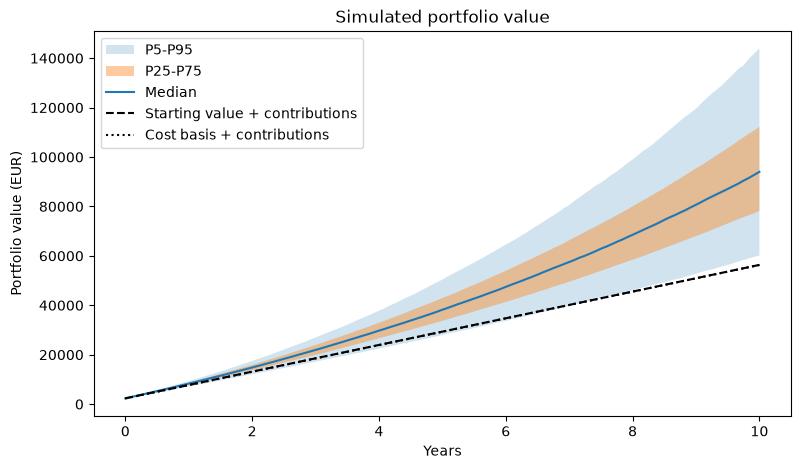

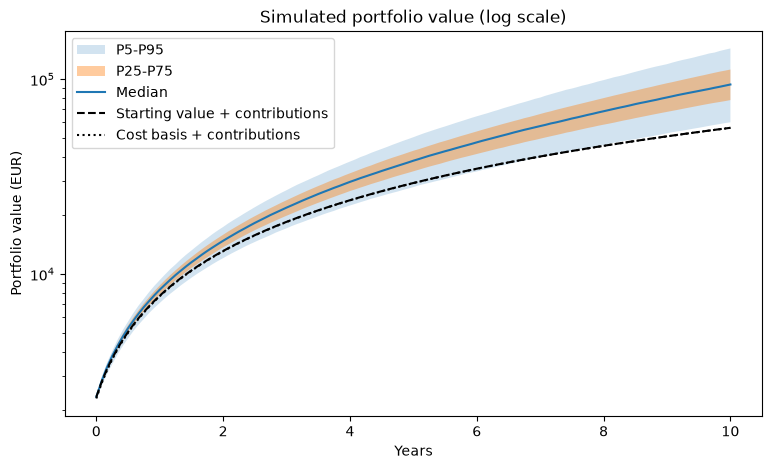

In [7]:
currency = cfg.portfolio.currency
fan = plot_fan_chart(total, contributed, currency, cost=cost)
fan_log = plot_fan_chart(total, contributed, currency, log_scale=True, cost=cost)
save_figure(fan, "fan_chart")
save_figure(fan_log, "fan_chart_log");

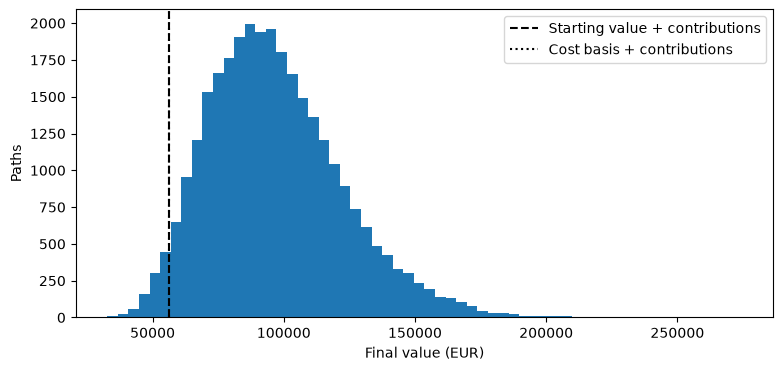

In [8]:
hist = plot_final_histogram(total, contributed, cfg.portfolio.currency, cost=cost)
save_figure(hist, "final_value_histogram");

### Asset weights over time

How the portfolio weights evolve over time. If the portfolio is rebalanced, the weights will converge to the target weights. If not, they will drift with the relative performance of each asset.


,Start,P5,P50,P95
MSCI World,55.6%,69.6%,75.4%,80.2%
Emerging Markets IMI,6.5%,6.6%,9.4%,13.5%
MSCI Europe,9.3%,10.1%,12.5%,15.6%
Physical Gold,28.7%,0.8%,2.1%,5.5%


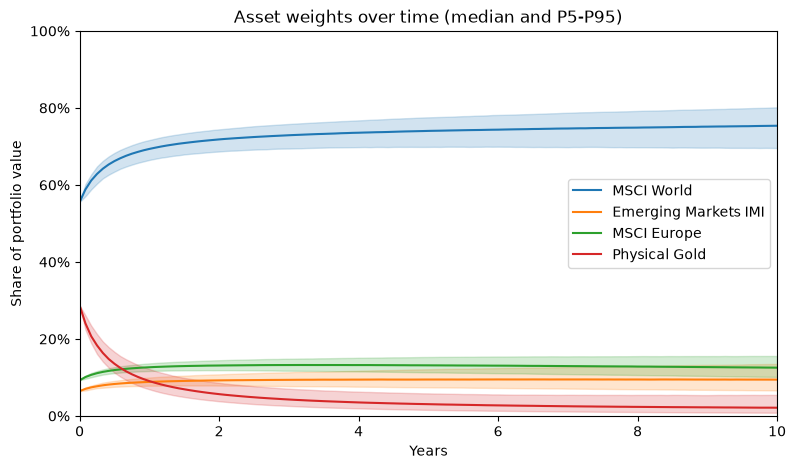

In [9]:
asset_names = [a.name for a in cfg.portfolio.assets]
display(weights_summary(paths, asset_names).map("{:.1%}".format))

weights_fig = plot_weights_over_time(paths, asset_names)
save_figure(weights_fig, "asset_weights");

## Short vs extended history

The same simulation run on the ETFs' own history only, and on the history extended with proxies. The ETF-only window is short and mostly a bull market, so it understates how bad things can get; the extended one includes 2008-09. P(loss) is the share of paths ending below the total contributed.

In [10]:
comparison = history_comparison(cfg, prices)
comparison.assign(
    **{col: comparison[col].astype(float).map("{:,.0f}".format) for col in ["P5", "P50", "P95"]},
    **{"P(loss)": comparison["P(loss)"].astype(float).map("{:.1%}".format)},
)

,From,Months,P5,P50,P95,P(loss)
ETFs only,2021-08,63,"77,486","108,169","151,293",0.1%
With proxies,2005-04,259,"60,130","94,000","143,930",3.1%


## Sensitivity to returns

Even the extended history is only one sample of the past. As a stress check, subtract a flat annual haircut from every historical return and re-run. Caveats: the proxies are not the real ETFs, and the past is not the future.

In [11]:
sens = sensitivity_to_haircut(cfg, returns)
sens.assign(**{c: sens[c].map("{:,.0f}".format) for c in ["P5", "P50", "P95"]}).assign(
    **{"P(loss)": sens["P(loss)"].map("{:.1%}".format)}
)

,P5,P50,P95,P(loss)
Baseline,"60,130","94,000","143,930",3.1%
-2%/yr,"53,845","83,447","126,879",7.0%
-4%/yr,"48,411","74,410","112,256",14.4%


## Sequence risk

Same returns, different order. Take the stretch of the portfolio's historical monthly returns that is as long as the simulation horizon and contains the worst 12-month block (placed as centrally as the history allows), and replay it three other ways: reversed, with the worst block moved to the start, and with it moved to the end. Every scenario has exactly the same returns, yet the final values differ once you contribute every month: a crash late in the horizon hits a large pot, while an early one only hits a small one.


Without contributions the order would not matter (multiplication commutes), so the gap below is entirely due to the monthly contributions.


In [12]:
port_returns = portfolio_return_series(cfg, returns)
initial_total = sum(a.initial_value for a in cfg.portfolio.assets)
monthly = cfg.simulation.monthly_contribution
n_months = cfg.simulation.horizon_years * 12

scenarios = sequence_risk_scenarios(
    port_returns, initial_total, monthly, window=12, n_months=n_months
)
seq_summary = sequence_risk_summary(scenarios)
seq_summary.map("{:,.2f}".format).to_frame()

,Final value
Historical order,"98,609.55"
Reversed,"90,003.58"
Worst block first,"113,195.58"
Worst block last,"79,167.16"


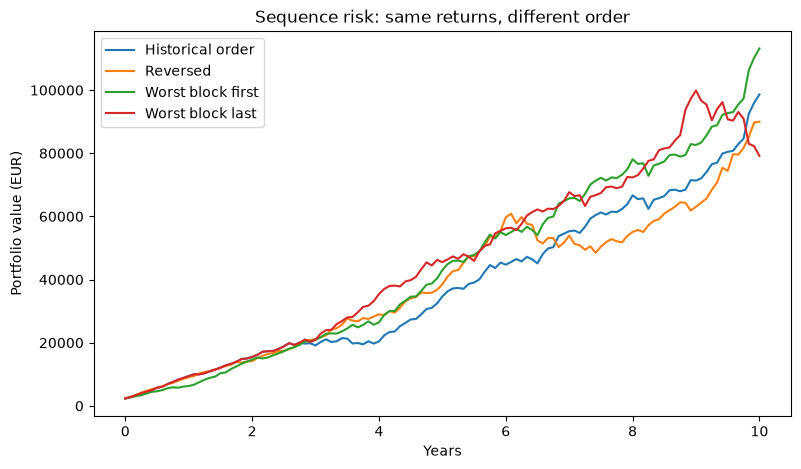

In [13]:
seq_fig = plot_sequence_risk(scenarios, cfg.portfolio.currency)
save_figure(seq_fig, "sequence_risk");

## Gain vs cost basis

How much the portfolio is worth compared with what was actually paid: `cost_basis` per asset plus the monthly contributions. Gain = simulated value − (cost basis + contributions).


In [14]:
gains = gain_summary(total, cost)
gains.map(lambda v: f"{v:,.2f}").assign(Return=gains["Return"].map("{:.1%}".format))

,Gain,Return
P5,"3,829.52",6.8%
P10,"10,101.80",17.9%
P25,"21,888.09",38.9%
P50,"37,699.68",67.0%
P75,"55,878.38",99.3%
P95,"87,630.09",155.6%


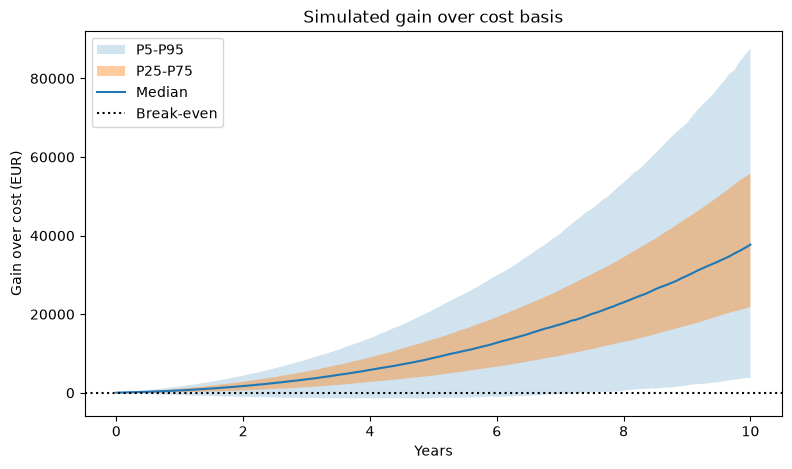

In [15]:
gain_fig = plot_gain_fan_chart(total, cost, cfg.portfolio.currency)
save_figure(gain_fig, "gain_fan_chart");

### Per asset

Final gain for each asset against its own cost basis plus its share of the contributions.


In [16]:
by_asset = gain_by_asset(
    paths, contributions_by_asset(cfg, "cost_basis"), [a.name for a in cfg.portfolio.assets]
)

formatted_by_asset = pd.DataFrame(
    {
        col: values.map("{:.1%}".format if col == "P50 return" else "{:,.2f}".format)
        for col, values in by_asset.items()
    }
)

formatted_by_asset

,Invested,P50 return,P5 gain,P10 gain,P25 gain,P50 gain,P75 gain,P95 gain
MSCI World,"42,000.00",68.1%,"2,436.07","7,336.61","16,426.09","28,587.14","42,699.90","67,465.10"
Emerging Markets IMI,"5,540.00",59.4%,-754.30,-59.35,"1,330.97","3,292.11","5,746.46","10,629.73"
MSCI Europe,"8,010.00",47.1%,-875.94,2.63,"1,632.87","3,770.93","6,390.95","10,888.62"
Physical Gold,750.05,166.1%,156.52,328.76,696.32,"1,245.52","2,008.20","3,637.65"
